In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/ball_by_ball_ipl.csv")
df.head()

,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,...,Chennai Super Kings,0,4,0,1,0,NaN,NaN,4,1
1,1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,...,Chennai Super Kings,0,4,0,2,0,NaN,NaN,0,1
2,2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,...,Chennai Super Kings,0,4,0,3,0,NaN,NaN,0,1
3,3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,...,Chennai Super Kings,0,4,0,4,0,NaN,NaN,0,1
4,4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,...,Chennai Super Kings,0,5,0,5,0,NaN,NaN,1,1


In [3]:
print(df.shape)
print(df.columns.tolist())

(239693, 35)
['Unnamed: 0', 'Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings', 'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs', 'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket', 'Method', 'Player Out', 'Innings Runs', 'Innings Wickets', 'Target Score', 'Runs to Get', 'Balls Remaining', 'Winner', 'Chased Successfully', 'Total Batter Runs', 'Total Non Striker Runs', 'Batter Balls Faced', 'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced', 'Bowler Runs Conceded', 'Valid Ball']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239693 entries, 0 to 239692
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               239693 non-null  int64  
 1   Match ID                 239693 non-null  int64  
 2   Date                     239693 non-null  str    
 3   Venue                    239693 non-null  str    
 4   Bat First                239693 non-null  str    
 5   Bat Second               239693 non-null  str    
 6   Innings                  239693 non-null  int64  
 7   Over                     239693 non-null  int64  
 8   Ball                     239693 non-null  int64  
 9   Batter                   239693 non-null  str    
 10  Non Striker              239693 non-null  str    
 11  Bowler                   239693 non-null  str    
 12  Batter Runs              239693 non-null  int64  
 13  Extra Runs               239693 non-null  int64  
 14  Runs From Ball 

In [5]:
df.isnull().sum()

Unnamed: 0                      0
Match ID                        0
Date                            0
Venue                           0
Bat First                       0
Bat Second                      0
Innings                         0
Over                            0
Ball                            0
Batter                          0
Non Striker                     0
Bowler                          0
Batter Runs                     0
Extra Runs                      0
Runs From Ball                  0
Ball Rebowled                   0
Extra Type                      0
Wicket                          0
Method                     227866
Player Out                 227866
Innings Runs                    0
Innings Wickets                 0
Target Score                    0
Runs to Get                123927
Balls Remaining                 0
Winner                          0
Chased Successfully             0
Total Batter Runs               0
Total Non Striker Runs          0
Batter Balls F

In [6]:
# Remove extra unnamed column
df = df.drop(columns=["Unnamed: 0"])

# Convert Date column into proper date format
df["Date"] = pd.to_datetime(df["Date"])

# Check again
df.head()

,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,1,0,NaN,NaN,4,1
1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,2,0,NaN,NaN,0,1
2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,3,0,NaN,NaN,0,1
3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,4,0,NaN,NaN,0,1
4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,5,0,5,0,NaN,NaN,1,1


In [7]:
print(df.shape)

(239693, 34)


In [8]:
top_batsmen = df.groupby("Batter")["Batter Runs"].sum().sort_values(ascending=False).head(10)
top_batsmen

Batter
V Kohli           7122
S Dhawan          6573
DA Warner         6310
RG Sharma         6165
SK Raina          5512
MS Dhoni          5082
AB de Villiers    5001
RV Uthappa        4941
CH Gayle          4875
KD Karthik        4408
Name: Batter Runs, dtype: int64

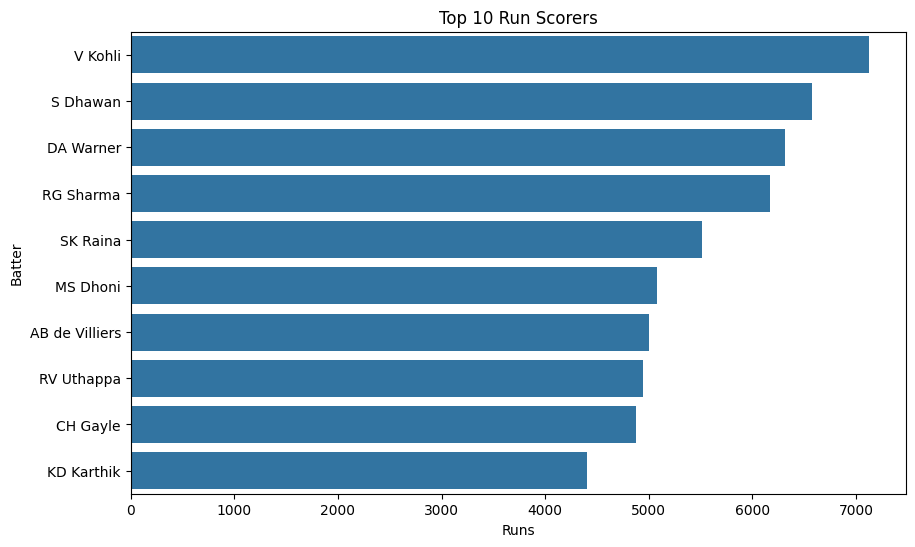

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index)
plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Batter")
plt.show()

In [10]:
batsman_runs = df.groupby("Batter")["Batter Runs"].sum()
balls_faced = df.groupby("Batter")["Valid Ball"].sum()

batting_stats = pd.concat([batsman_runs, balls_faced], axis=1)
batting_stats.columns = ["Runs", "Balls"]

batting_stats["Strike Rate"] = (batting_stats["Runs"] / batting_stats["Balls"]) * 100

batting_stats.head()

,Runs,Balls,Strike Rate
Batter,,,
A Ashish Reddy,266,181,146.961326
A Badoni,340,268,126.865672
A Chandila,4,7,57.142857
A Chopra,53,71,74.647887
A Choudhary,25,20,125.000000


In [11]:
batting_stats.sort_values("Runs", ascending=False).head(10)

,Runs,Balls,Strike Rate
Batter,,,
V Kohli,7122,5450,130.678899
S Dhawan,6573,5145,127.755102
DA Warner,6310,4487,140.628482
RG Sharma,6165,4712,130.836163
SK Raina,5512,4008,137.524950
MS Dhoni,5082,3718,136.686391
AB de Villiers,5001,3288,152.098540
RV Uthappa,4941,3775,130.887417
CH Gayle,4875,3244,150.277435


In [12]:
fours = df[df["Batter Runs"] == 4].groupby("Batter").size()
sixes = df[df["Batter Runs"] == 6].groupby("Batter").size()

batting_stats = batting_stats.join(fours.rename("Fours"), how="left")
batting_stats = batting_stats.join(sixes.rename("Sixes"), how="left")

batting_stats = batting_stats.fillna(0)
batting_stats.head()

,Runs,Balls,Strike Rate,Fours,Sixes
Batter,,,,,
A Ashish Reddy,266,181,146.961326,16.0,14.0
A Badoni,340,268,126.865672,22.0,15.0
A Chandila,4,7,57.142857,0.0,0.0
A Chopra,53,71,74.647887,7.0,0.0
A Choudhary,25,20,125.000000,1.0,1.0


In [13]:
top_bowlers = df[df["Wicket"] == 1].groupby("Bowler").size().sort_values(ascending=False).head(10)
top_bowlers

Bowler
DJ Bravo           207
YS Chahal          189
PP Chawla          186
SL Malinga         186
R Ashwin           186
B Kumar            183
SP Narine          182
A Mishra           179
RA Jadeja          160
Harbhajan Singh    160
dtype: int64

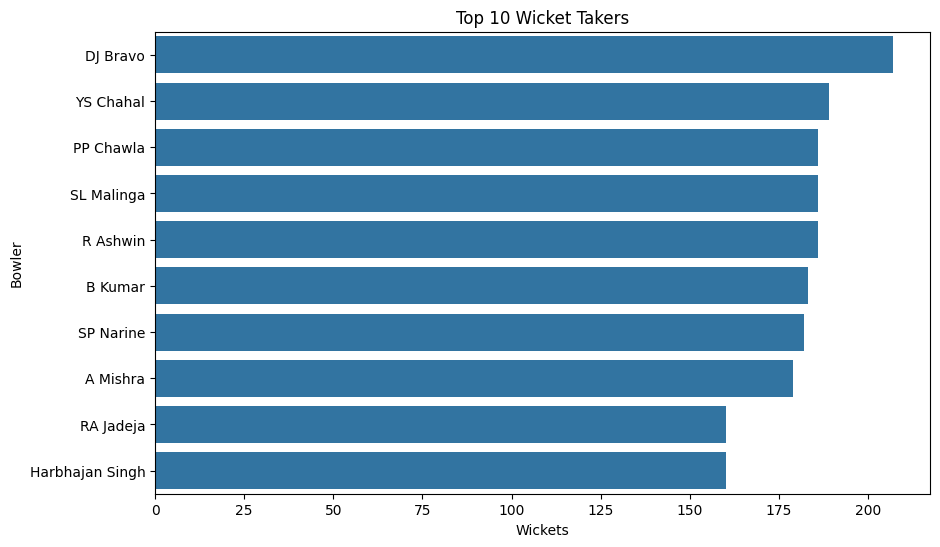

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index)
plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

In [15]:
runs_conceded = df.groupby("Bowler")["Bowler Runs Conceded"].sum()
balls_bowled = df.groupby("Bowler")["Valid Ball"].sum()

bowling_stats = pd.concat([runs_conceded, balls_bowled], axis=1)
bowling_stats.columns = ["Runs Conceded", "Balls"]

bowling_stats["Overs"] = bowling_stats["Balls"] / 6
bowling_stats["Economy"] = bowling_stats["Runs Conceded"] / bowling_stats["Overs"]

bowling_stats.head()

,Runs Conceded,Balls,Overs,Economy
Bowler,,,,
A Ashish Reddy,389,256,42.666667,9.117188
A Badoni,11,13,2.166667,5.076923
A Chandila,242,234,39.000000,6.205128
A Choudhary,144,101,16.833333,8.554455
A Dananjaya,47,24,4.000000,11.750000


In [16]:
bowling_stats[bowling_stats["Balls"] > 100].sort_values("Economy").head(10)

,Runs Conceded,Balls,Overs,Economy
Bowler,,,,
A Chandila,242,234,39.000000,6.205128
Sohail Tanvir,266,247,41.166667,6.461538
SMSM Senanayake,209,192,32.000000,6.531250
SM Pollock,301,276,46.000000,6.543478
A Kumble,1058,965,160.833333,6.578238
FH Edwards,154,140,23.333333,6.600000
GD McGrath,357,324,54.000000,6.611111
Rashid Khan,2805,2525,420.833333,6.665347
IS Sodhi,202,181,30.166667,6.696133


In [17]:
dot_balls = df[df["Runs From Ball"] == 0].groupby("Bowler").size()

bowling_stats = bowling_stats.join(dot_balls.rename("Dot Balls"), how="left")
bowling_stats = bowling_stats.fillna(0)

bowling_stats["Dot Ball %"] = (bowling_stats["Dot Balls"] / bowling_stats["Balls"]) * 100
bowling_stats.head()

,Runs Conceded,Balls,Overs,Economy,Dot Balls,Dot Ball %
Bowler,,,,,,
A Ashish Reddy,389,256,42.666667,9.117188,77.0,30.078125
A Badoni,11,13,2.166667,5.076923,4.0,30.769231
A Chandila,242,234,39.000000,6.205128,103.0,44.017094
A Choudhary,144,101,16.833333,8.554455,42.0,41.584158
A Dananjaya,47,24,4.000000,11.750000,6.0,25.000000


In [18]:
bowling_stats[bowling_stats["Balls"] > 100].sort_values("Dot Ball %", ascending=False).head(10)

,Runs Conceded,Balls,Overs,Economy,Dot Balls,Dot Ball %
Bowler,,,,,,
Simarjeet Singh,138,108,18.000000,7.666667,55.0,50.925926
FH Edwards,154,140,23.333333,6.600000,70.0,50.000000
Mohsin Khan,304,258,43.000000,7.069767,127.0,49.224806
Sohail Tanvir,266,247,41.166667,6.461538,121.0,48.987854
R Rampaul,270,238,39.666667,6.806723,116.0,48.739496
GD McGrath,357,324,54.000000,6.611111,153.0,47.222222
M Ntini,242,210,35.000000,6.914286,99.0,47.142857
SM Pollock,301,276,46.000000,6.543478,130.0,47.101449
DW Steyn,2471,2152,358.666667,6.889405,1010.0,46.933086


In [19]:
team_wins = df.groupby("Winner")["Match ID"].nunique().sort_values(ascending=False)
team_wins

Winner
Mumbai Indians                 138
Chennai Super Kings            131
Kolkata Knight Riders          119
Royal Challengers Bangalore    114
Rajasthan Royals               101
Kings XI Punjab                 85
Sunrisers Hyderabad             78
Delhi Daredevils                67
Delhi Capitals                  38
Deccan Chargers                 29
Gujarat Titans                  23
Punjab Kings                    19
Lucknow Super Giants            17
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: Match ID, dtype: int64

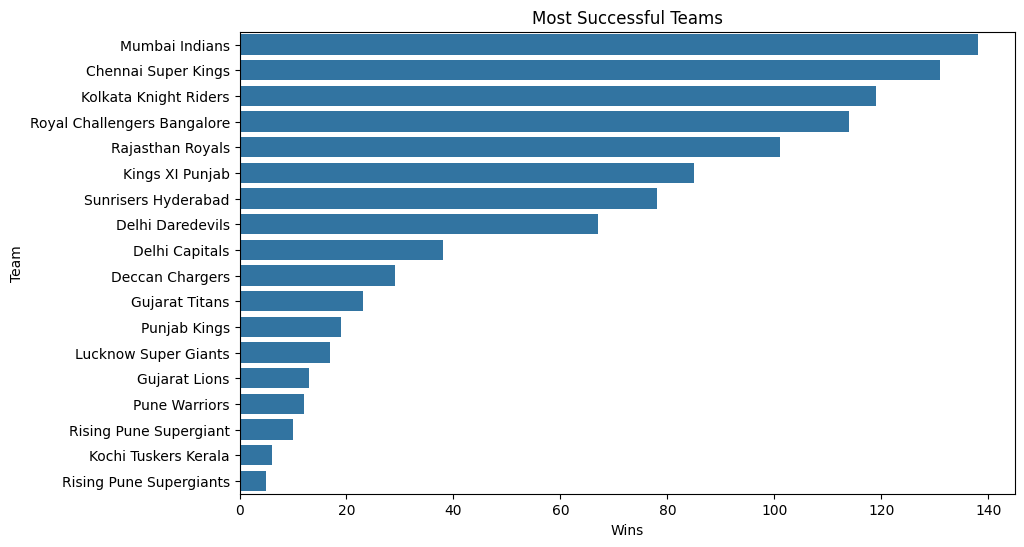

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x=team_wins.values, y=team_wins.index)
plt.title("Most Successful Teams")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.show()

In [21]:
chase_success = df.groupby("Match ID")["Chased Successfully"].max().mean() * 100
print(f"Chasing success rate: {chase_success:.2f}%")

Chasing success rate: 54.53%


In [22]:
venue_matches = df.groupby("Venue")["Match ID"].nunique().sort_values(ascending=False).head(10)
venue_matches

Venue
Wankhede Stadium                           110
Eden Gardens                                86
MA Chidambaram Stadium                      74
Rajiv Gandhi International Stadium          70
M Chinnaswamy Stadium                       69
Feroz Shah Kotla                            59
Sawai Mansingh Stadium                      52
Dubai International Cricket Stadium         43
Dr DY Patil Sports Academy                  37
Maharashtra Cricket Association Stadium     35
Name: Match ID, dtype: int64

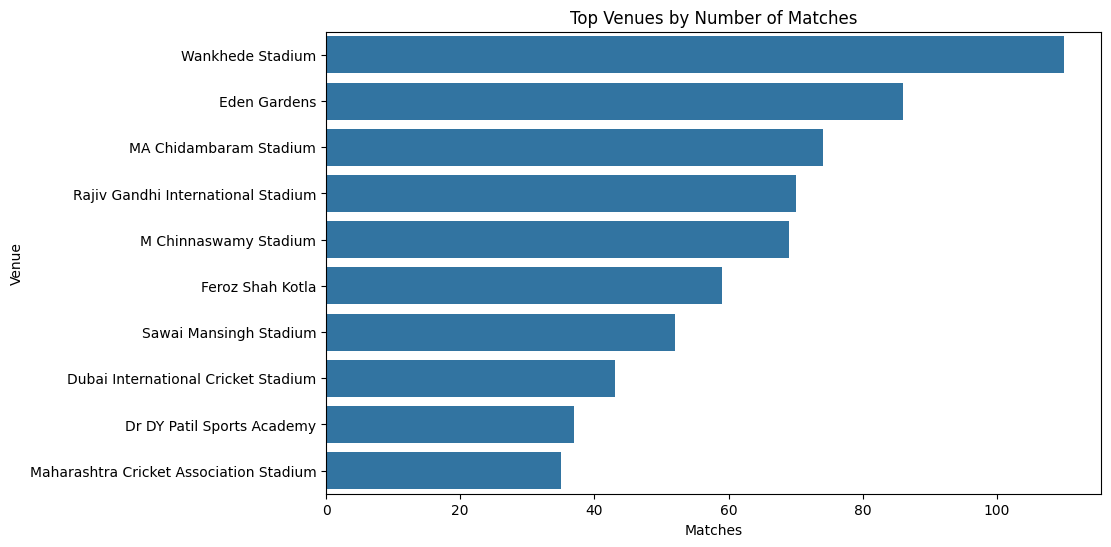

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=venue_matches.values, y=venue_matches.index)
plt.title("Top Venues by Number of Matches")
plt.xlabel("Matches")
plt.ylabel("Venue")
plt.show()

In [25]:
players = ["V Kohli", "RG Sharma"]
comparison = batting_stats.loc[players, ["Runs", "Strike Rate", "Fours", "Sixes"]]
comparison

,Runs,Strike Rate,Fours,Sixes
Batter,,,,
V Kohli,7122,130.678899,631.0,230.0
RG Sharma,6165,130.836163,547.0,257.0


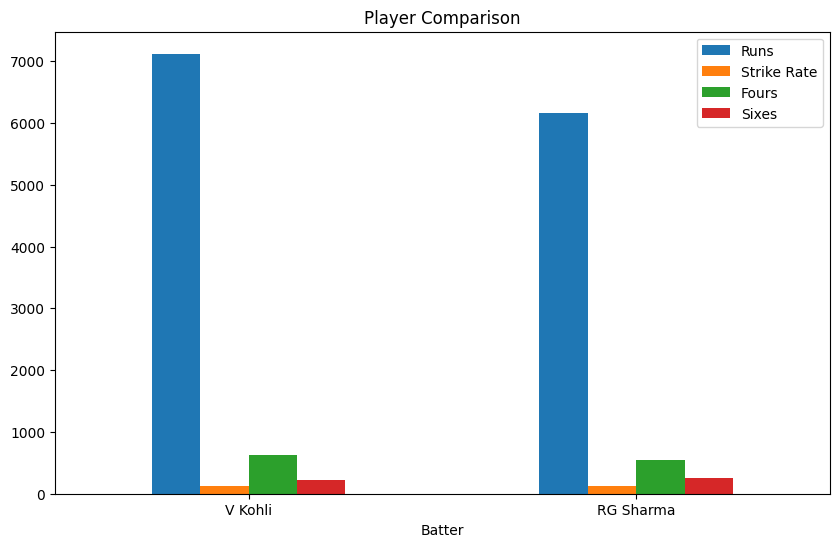

In [26]:
comparison.plot(kind="bar", figsize=(10, 6))
plt.title("Player Comparison")
plt.xticks(rotation=0)
plt.show()

In [27]:
match_runs = df.groupby(["Match ID", "Batter"])["Batter Runs"].sum().reset_index()

consistency = match_runs.groupby("Batter").agg(
    Matches=("Match ID", "nunique"),
    Average_Runs=("Batter Runs", "mean"),
    Fifties=("Batter Runs", lambda x: (x >= 50).sum())
)

consistency.sort_values("Average_Runs", ascending=False).head(10)

,Matches,Average_Runs,Fifties
Batter,,,
Vivrant Sharma,1,69.000000,1
DP Conway,22,42.000000,9
B Sai Sudharsan,13,39.000000,4
KL Rahul,105,38.600000,36
LMP Simmons,29,37.206897,12
RM Patidar,11,36.727273,3
DA Warner,172,36.686047,65
CH Gayle,135,36.111111,37
HM Amla,16,36.062500,5


In [28]:
consistency[consistency["Matches"] >= 20].sort_values("Average_Runs", ascending=False).head(10)

,Matches,Average_Runs,Fifties
Batter,,,
DP Conway,22,42.000000,9
KL Rahul,105,38.600000,36
LMP Simmons,29,37.206897,12
DA Warner,172,36.686047,65
CH Gayle,135,36.111111,37
SE Marsh,68,35.470588,20
RD Gaikwad,51,35.235294,15
ML Hayden,31,34.645161,8
JC Buttler,94,34.191489,24


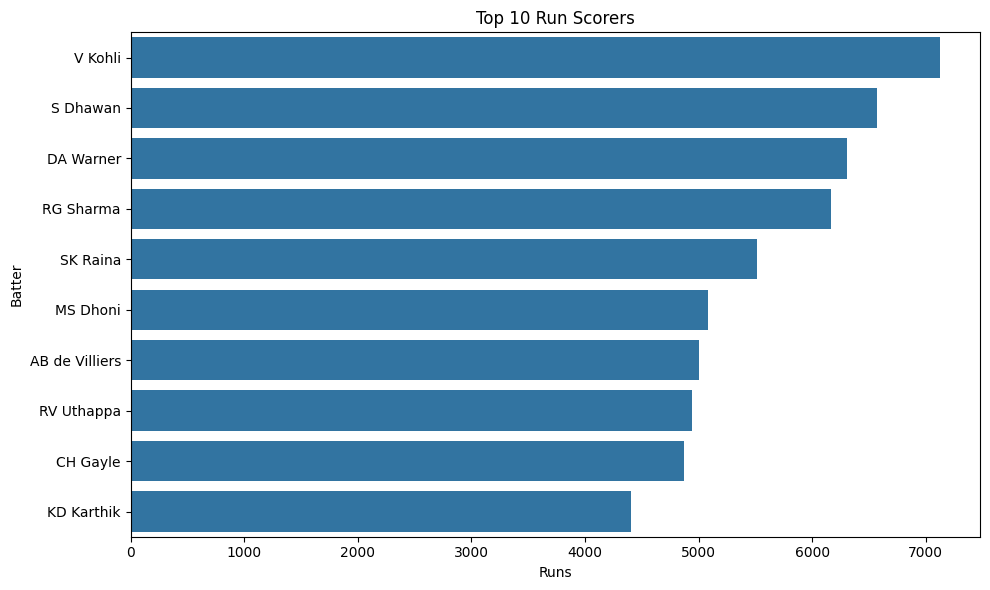

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index)
plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Batter")
plt.tight_layout()
plt.savefig("../outputs/top_batsmen.png")
plt.show()

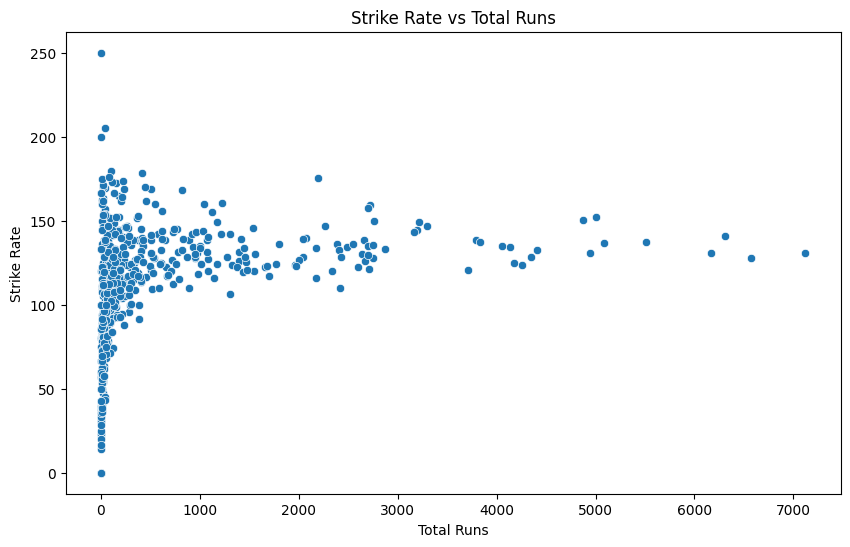

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=batting_stats,
    x="Runs",
    y="Strike Rate"
)

plt.title("Strike Rate vs Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Strike Rate")
plt.show()

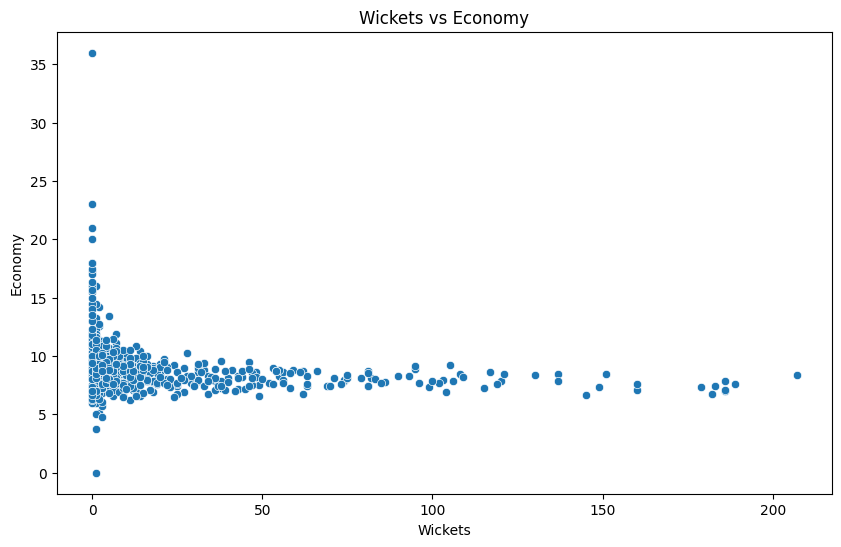

In [31]:
# Merge wickets with bowling stats
wickets_all = df[df["Wicket"] == 1].groupby("Bowler").size()

bowling_stats = bowling_stats.join(wickets_all.rename("Wickets"), how="left")
bowling_stats.fillna(0, inplace=True)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=bowling_stats,
    x="Wickets",
    y="Economy"
)

plt.title("Wickets vs Economy")
plt.xlabel("Wickets")
plt.ylabel("Economy")
plt.show()

In [32]:
df["Year"] = df["Date"].dt.year

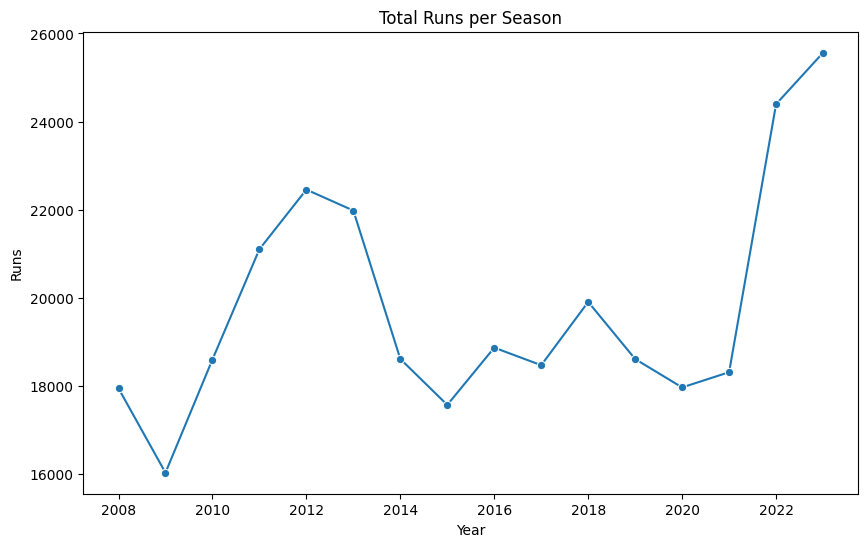

In [33]:
season_runs = df.groupby("Year")["Runs From Ball"].sum()

plt.figure(figsize=(10,6))
sns.lineplot(x=season_runs.index, y=season_runs.values, marker="o")

plt.title("Total Runs per Season")
plt.xlabel("Year")
plt.ylabel("Runs")
plt.show()

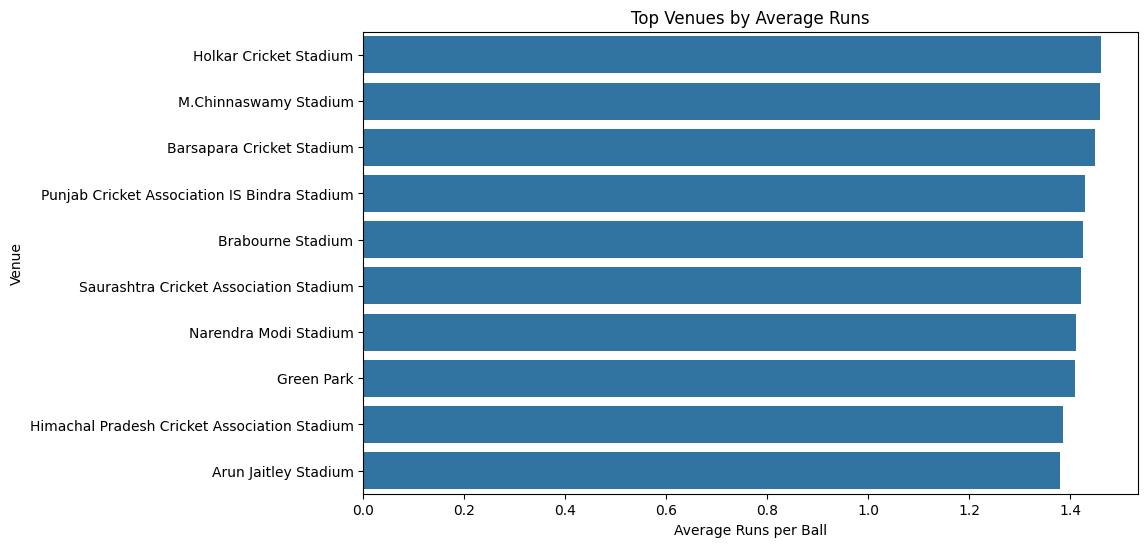

In [34]:
venue_runs = df.groupby("Venue")["Runs From Ball"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=venue_runs.values, y=venue_runs.index)

plt.title("Top Venues by Average Runs")
plt.xlabel("Average Runs per Ball")
plt.ylabel("Venue")
plt.show()